### Check that the tracking and processing works

In [1]:
import os
if os.getcwd().endswith("notebooks"):
    os.chdir("../")

from src.tracking.tracker import MediapipeHandTracker
from src.tracking.preprocessing import TrajectoryProcessor, LandmarksProcessor
from src.tracking.visualization import draw_hands, draw_hand_trajectories, compare_trajectories, draw_hand_trajectories_new, compare_trajectories_new
from tqdm import tqdm
import pandas as pd

In [2]:
FPS = 30

if FPS == 30:
    max_jump_px = 100
    max_gap_sec = 0.1
else:
    max_jump_px = 100
    max_gap_sec = 0.2

tracker = MediapipeHandTracker(target_fps=FPS)
processor = LandmarksProcessor(fps=FPS, max_jump_px=max_jump_px, max_gap_sec=max_gap_sec)

In [4]:
video_path = "data/videos/Study1_Videos/2024-01-15_13-18-23.mp4"
#video_path = "data/videos/Study1_Videos/test_clip.mp4"
df = tracker.track_video(video_path, overwrite=False)
df_processed = processor.process(df)

⏭️ Skipping 2024-01-15_13-18-23 (already processed)


In [4]:
df_processed.head()


,frame,hand_label,hand_score,palm_center,frame_diff,segment_id,lm_0_x_smooth,lm_0_y_smooth,lm_5_x_smooth,lm_5_y_smooth,lm_17_x_smooth,lm_17_y_smooth,cx_smooth,cy_smooth
0,0,Left,0.915899,"(1141.3394737243652, 536.9848483800888)",NaN,0,1174.285455,552.132727,1096.434545,513.420000,1175.219394,564.222424,1141.995036,539.662552
1,0,Right,0.959138,"(844.4436740875244, 497.16905415058136)",NaN,0,817.698182,457.813333,862.403636,481.992727,844.478182,526.575152,844.743108,488.193770
2,1,Right,0.979843,"(852.5309085845947, 487.37443685531616)",1.0,0,825.297879,457.010000,864.870909,481.391515,849.674545,527.532121,849.610100,488.331138
3,1,Left,0.981274,"(1146.0855674743652, 543.7231206893921)",1.0,0,1178.066364,555.571515,1096.856970,511.523333,1175.911515,565.437273,1143.450291,540.621784
4,2,Right,0.996646,"(851.4857482910156, 491.21244728565216)",1.0,0,831.570519,456.225714,867.311342,480.943983,854.450996,528.735195,853.973836,488.524738


In [4]:
df_processed.to_pickle("data/processed/short_10fps_processed.pkl")


In [5]:
df_processed_old = pd.read_pickle("data/processed/hand_tracking_2024-01-15_13-37-36_30fps_processed.pkl")
df_processed_old

,frame,hand_label,hand_score,bbox_center,palm_center,landmarks,frame_diff,segment_id,cx_smooth,cy_smooth
0,0,Left,0.993872,"(367, 532)","(403, 513)","[{'id': 0, 'coord': (0.2253393679857254, 0.442...",NaN,0,403.000000,513.000000
1,0,Right,0.987037,"(134, 551)","(94, 554)","[{'id': 0, 'coord': (0.0497935526072979, 0.521...",NaN,0,92.321212,553.175758
2,1,Left,0.990046,"(354, 521)","(384, 501)","[{'id': 0, 'coord': (0.21805785596370697, 0.43...",1.0,0,384.000000,501.000000
3,1,Right,0.987748,"(162, 536)","(116, 535)","[{'id': 0, 'coord': (0.05766121298074722, 0.51...",1.0,0,109.096970,541.593939
4,2,Left,0.997346,"(354, 524)","(383, 502)","[{'id': 0, 'coord': (0.2177249640226364, 0.434...",1.0,0,383.000000,502.000000
...,...,...,...,...,...,...,...,...,...,...
13568,8637,Right,NaN,NaN,NaN,NaN,1.0,40,656.599278,506.164069
13569,8638,Left,0.987801,"(655, 570)","(670, 577)","[{'id': 0, 'coord': (0.3831747770309448, 0.526...",1.0,68,670.000000,577.000000
13570,8638,Right,NaN,NaN,NaN,NaN,1.0,40,604.268687,509.493939
13571,8639,Left,0.969998,"(622, 570)","(646, 581)","[{'id': 0, 'coord': (0.37027764320373535, 0.53...",1.0,68,646.000000,581.000000


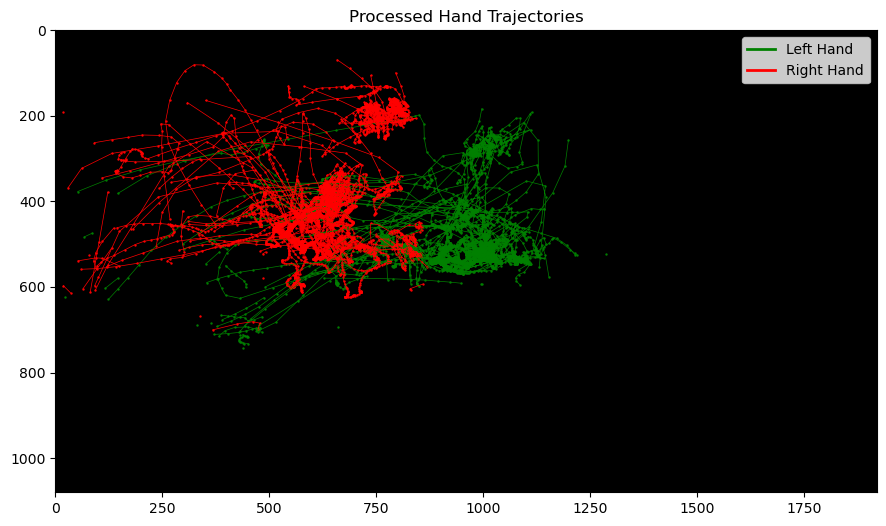

In [9]:
df_hand_left = df_processed[df_processed['hand_label'] == 'Left']
df_hand_right = df_processed[df_processed['hand_label'] == 'Right']
draw_hands(df_hand_left, df_hand_right, title="Processed Hand Trajectories")

#df_hand_left_old = df_processed_old[df_processed_old['hand_label'] == 'Left']
#df_hand_right_old = df_processed_old[df_processed_old['hand_label'] == 'Right']
#draw_hands(df_hand_left_old, df_hand_right_old, title="Old Processed Hand Trajectories")

In [10]:
df_processed

,frame,hand_label,hand_score,palm_center,frame_diff,segment_id,lm_0_x_smooth,lm_0_y_smooth,lm_5_x_smooth,lm_5_y_smooth,lm_17_x_smooth,lm_17_y_smooth,cx_smooth,cy_smooth
0,51,Right,0.992935,"(494, 287)",NaN,0,442.157143,256.365714,526.005714,263.065714,496.211429,345.825714,493.714286,286.171429
1,54,Right,0.994395,"(498, 283)",3.0,0,443.051429,255.497143,531.937143,261.837143,501.694286,345.577143,498.342857,284.914286
2,57,Right,0.992038,"(504, 285)",3.0,0,446.402857,254.814286,540.054286,261.394286,507.948571,345.414286,504.685714,284.228571
3,60,Right,0.990775,"(514, 285)",3.0,0,453.108571,255.031429,551.220000,262.840000,515.654286,345.785714,513.571429,284.914286
4,63,Right,0.990049,"(522, 284)",3.0,0,459.260000,253.594286,561.631429,262.365714,522.677143,345.394286,521.657143,284.171429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,579,Right,0.999363,"(402, 125)",12.0,1,452.400000,140.200000,379.800000,80.400000,384.100000,171.400000,402.000000,125.000000
309,579,Left,0.996263,"(1097, 524)",3.0,3,1129.742857,508.100000,1087.965714,495.405714,1082.477143,575.691429,1097.428571,523.571429
310,582,Left,0.996078,"(1097, 523)",3.0,3,1130.431429,508.180000,1088.962857,495.442857,1082.268571,575.045714,1097.714286,523.485714
311,585,Right,0.998730,"(305, 273)",6.0,1,359.700000,280.300000,274.600000,240.900000,292.800000,314.600000,305.000000,273.000000


In [9]:
video_path = "data/videos/Study1_Videos/2024-01-15_13-18-23.mp4"
draw_hand_trajectories_new(video_path, df_processed=df_processed, fps=30, tail_length=30)

Drawing trajectories for: 2024-01-15_13-18-23


100%|██████████| 16212/16212 [07:42<00:00, 35.02frames/s]


✅ Video saved to: data/experiments/2024-01-15_13-18-23_trajectories_30fps.mp4


'data/experiments/2024-01-15_13-18-23_trajectories_30fps.mp4'

In [ ]:
video_path = "data/videos/Study1_Videos/2024-01-15_13-37-36.mp4"
compare_trajectories_new(video_path, df_30_fps=None, df_10_fps=None, tail_length=30)

Annotating All Landmarks: 100%|█████████▉| 586/588 [00:26<00:00, 22.12frames/s]


'data/experiments/short_comparison.mp4'

## Process all dataframes

In [2]:
FPS = 30
if FPS == 30:
    max_jump_px = 100
    max_gap_sec = 0.1
else:
    max_jump_px = 100
    max_gap_sec = 0.2


out_dir = "data/raw/output_dataframes/"
processed_dir = "data/processed/landmark_dataframes2/"

tracked_dataframes = [f for f in os.listdir(out_dir) if f.endswith(f'_{FPS}fps.pkl')]
processed_dataframes = [f for f in os.listdir(processed_dir) if f.endswith(f'_{FPS}fps_processed.pkl')]

processor = LandmarksProcessor(fps=FPS, max_jump_px=max_jump_px, max_gap_sec=max_gap_sec)

for df_name in tqdm(tracked_dataframes):
    #if df_name.replace(f'_{FPS}fps.pkl', f'_{FPS}fps_processed.pkl') in processed_dataframes:
        #continue  # already processed

    df = pd.read_pickle(os.path.join(out_dir, df_name))
    
    processed_df = processor.process(df)
    processed_df.to_pickle(os.path.join(processed_dir, df_name.replace(f'_{FPS}fps.pkl', f'_{FPS}fps_processed.pkl')))

100%|██████████| 88/88 [25:44<00:00, 17.55s/it]
